In [1]:
import numpy as np
import pandas as pd
import xarray as xr
import matplotlib.pyplot as plt
import cartopy.crs as ccrs
import cartopy.feature as cf
import matplotlib as mpl
from pylab import *
import matplotlib
from matplotlib import cm
from matplotlib.colors import ListedColormap, LinearSegmentedColormap

ERROR 1: PROJ: proj_create_from_database: Open of /nesi/project/niwa00018/queenle/ml_env_v2/share/proj failed


In [2]:
'''
Create vegetation land masks
'''
ERA5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/FWI_6month_fire_season_ERA5_resolution.nc')
d4pdf = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc')
cam5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_All_ensMean.nc')

vege_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/ERA5/monthly/vegetation/1951-2021.nc')
vege_ds['longitude'] = [lon + 360 for lon in vege_ds.longitude.data]
era5_combined = (vege_ds.lai_hv + vege_ds.lai_lv).max('time')
era5_vege_mask = era5_combined.where(era5_combined>3.5)

vege_ds_coarsened = vege_ds.coarsen(latitude=3,longitude=3,boundary='pad').mean()

cam5_vege = vege_ds_coarsened.interp(longitude=cam5.longitude, latitude=cam5.latitude, method="linear")
cam5_combined = (cam5_vege.lai_hv + cam5_vege.lai_lv).max('time')
cam5_vege_mask = cam5_combined.where(cam5_combined>3.5)

d4pdf_vege = vege_ds_coarsened.interp(longitude=d4pdf.longitude, latitude=d4pdf.latitude, method="linear")
d4pdf_combined = (d4pdf_vege.lai_hv + d4pdf_vege.lai_lv).max('time')
d4pdf_vege_mask = d4pdf_combined.where(d4pdf_combined>3.5)

box = [(32,55),(232,256)]

def get_linregress_slope(arr):
    if (np.isnan(arr)).any():
        result = np.nan
    else:
        result = np.polyfit([i for i in range(len(arr))],arr,deg=1)[0]
        
    return(result)

ERA5 = ERA5.where(era5_vege_mask>0)
d4pdf = d4pdf.where(d4pdf_vege_mask>0)
cam5 = cam5.where(cam5_vege_mask>0)

In [3]:
# get d4PDF data
era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')
Ant_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_Ant_ensMean.nc')
Nat_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_NAT_ensMean.nc')
noise_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/noise/absolute_noise/FWI_absolute_noise_all_and_nat_ensMean.nc')

Ant_da = Ant_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
Ant_da = Ant_da.sel(time=slice('1951','2021'))
Ant_da = Ant_da.where(d4pdf_vege_mask>0)
Ant_da = Ant_da.where(~era5_da.isnull())

Nat_da = Nat_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
Nat_da = Nat_da.sel(time=slice('1951','2021'))
Nat_da = Nat_da.where(d4pdf_vege_mask>0)
Nat_da = Nat_da.where(~era5_da.isnull())

d4PDF_array = [Ant_da, Nat_da, noise_da]

# get CAM5 data
era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/cam5_resolution/FWI_6month_fire_season_cam5_resolution.nc')
Ant_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_Ant_ensMean.nc')
Nat_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_Nat_ensMean.nc')
noise_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/noise/absolute_noise/FWI_absolute_noise_all_and_nat_ensMean.nc')

Ant_da = Ant_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
Ant_da = Ant_da.sel(time=slice('1959','2014'))
Ant_da = Ant_da.where(cam5_vege_mask>0)
Ant_da = Ant_da.where(~era5_da.isnull())

Nat_da = Nat_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
Nat_da = Nat_da.sel(time=slice('1959','2014'))
Nat_da = Nat_da.where(cam5_vege_mask>0)
Nat_da = Nat_da.where(~era5_da.isnull())

CAM5_array = [Ant_da, Nat_da, noise_da]



In [4]:
def setup_figure():
    
    gs = fig.add_gridspec(8,12)
    #gs.update(wspace=2, hspace=0.3)

    # subregion map
    ax1 = fig.add_subplot(gs[2:6, 0:4], projection=ccrs.PlateCarree())
    ax1.coastlines(resolution='auto', color='k')
    ax1.set_extent([232.5,255, 32.5,54.18], crs=ccrs.PlateCarree())

    # subregion timeseries
    ax2 = fig.add_subplot(gs[0:2, 4:8])
    plt.setp(ax2.get_xticklabels(), visible=False)

    ax3 = fig.add_subplot(gs[0:2, 8:12])
    plt.setp(ax3.get_xticklabels(), visible=False)

    ax4 = fig.add_subplot(gs[2:4, 4:8], sharex=ax3)
    plt.setp(ax4.get_xticklabels(), visible=False)

    ax5 = fig.add_subplot(gs[2:4, 8:12], sharex=ax4)
    plt.setp(ax5.get_xticklabels(), visible=False)

    ax6 = fig.add_subplot(gs[4:6, 4:8], sharex=ax3)
    plt.setp(ax6.get_xticklabels(), visible=False)

    ax7 = fig.add_subplot(gs[4:6, 8:12], sharex=ax4)
    plt.setp(ax7.get_xticklabels(), visible=False)

    ax8 = fig.add_subplot(gs[6:8, 4:8], sharex=ax3)

    ax9 = fig.add_subplot(gs[6:8, 8:12], sharex=ax4)


    return((ax1,[ax2,ax4,ax6,ax8],[ax3,ax5,ax7,ax9]))

In [5]:
def get_cmaps():

    cmaps = []
    for c in colors:
        viridis = matplotlib.colormaps['viridis']
        newcolors = viridis(np.linspace(0, 1, 256))
        newcolors[-25:, :] = matplotlib.colors.to_rgba(c, alpha=0.5)
        newcmp = ListedColormap(newcolors)

        cmaps.append(newcmp)
        
    return(cmaps)

In [6]:
def get_weighted_da(da):
    
    weights = np.cos(np.deg2rad(da.latitude))
    weights.name = "weights"
    weighted_da = da.weighted(weights)

    return(weighted_da)

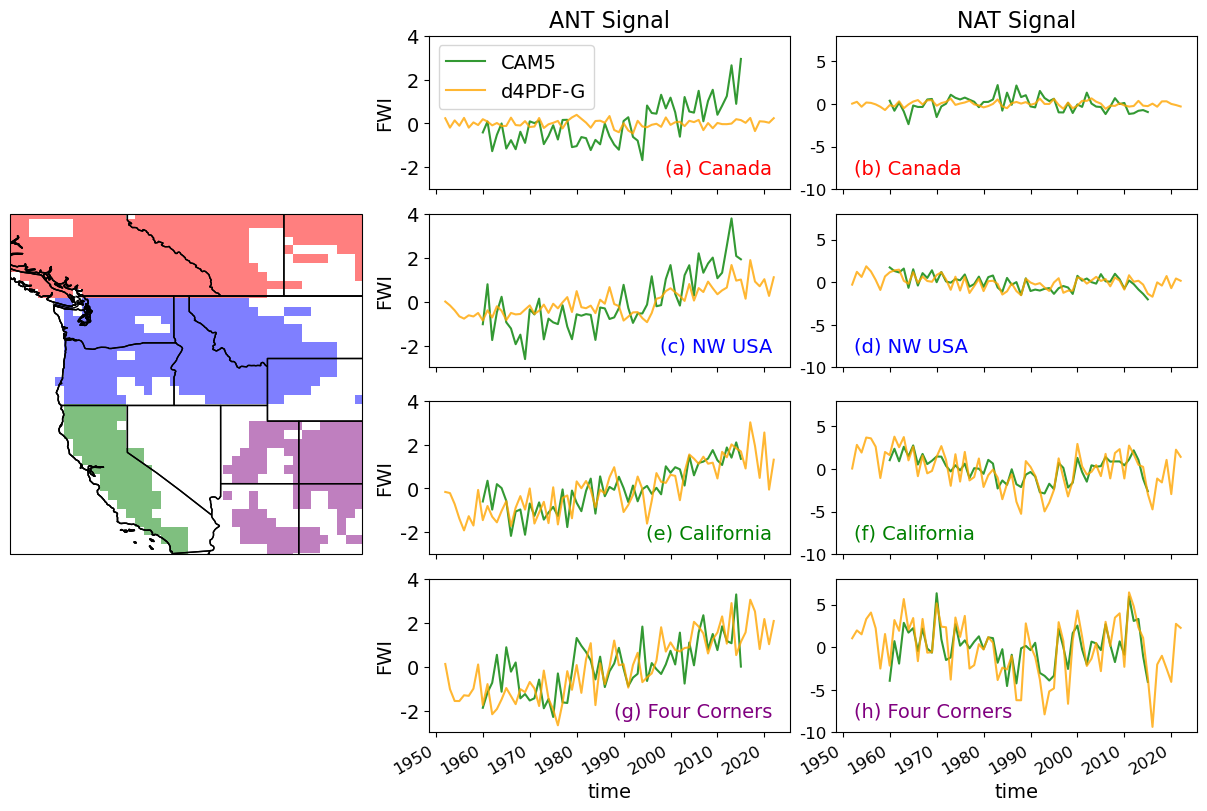

In [13]:
subregions = {'Canada':[49,55,232,255],'NW USA':[42,49,232,255],
              'California':[32,42,232,244],'Four Corners':[32,41,246,256]}

fig = plt.figure(figsize=(12,8),layout='constrained')
map_ax,ant_axs,nat_axs = setup_figure()

font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 14,
        }

# PLOT MAP of subregions
colors = ['red','blue','green','purple']
cmaps = get_cmaps()

for i,subregion in enumerate(subregions):

    sr = subregions[subregion]
    four_corners = d4pdf.sel(latitude=slice(sr[0],sr[1]),longitude=slice(sr[2],sr[3]))
    four_corners.max('time').plot(ax=map_ax,cmap=cmaps[i],vmin=0,vmax=0.1,add_colorbar=False)

map_ax.coastlines()  # cartopy function
map_ax.add_feature(cf.BORDERS)
map_ax.add_feature(cf.STATES)
map_ax.set_extent([232.5,255, 32.5,54.18])

# plot signal time series
subplot_labels = ['(a)','(b)','(c)','(d)','(e)','(f)','(g)','(h)','(i)']
for i,subregion in enumerate(subregions):

    sr = subregions[subregion]
    
    cam5_ant_sr = CAM5_array[0].sel(latitude=slice(sr[0],sr[1]),longitude=slice(sr[2],sr[3]))
    cam5_ant_sr = cam5_ant_sr-cam5_ant_sr.mean('time')
    get_weighted_da(cam5_ant_sr).mean(['latitude','longitude']).plot(ax=ant_axs[i],label='CAM5',c='green',alpha=0.8)
    
    d4pdf_ant_sr = d4PDF_array[0].sel(latitude=slice(sr[0],sr[1]),longitude=slice(sr[2],sr[3]))
    d4pdf_ant_sr = d4pdf_ant_sr-d4pdf_ant_sr.mean('time')
    get_weighted_da(d4pdf_ant_sr).mean(['latitude','longitude']).plot(ax=ant_axs[i],label='d4PDF-G',c='orange',alpha=0.8)

    cam5_nat_sr = CAM5_array[1].sel(latitude=slice(sr[0],sr[1]),longitude=slice(sr[2],sr[3]))
    cam5_nat_sr = cam5_nat_sr-cam5_nat_sr.mean('time')
    get_weighted_da(cam5_nat_sr).mean(['latitude','longitude']).plot(ax=nat_axs[i],label='CAM5',c='green',alpha=0.8)

    d4pdf_nat_sr = d4PDF_array[1].sel(latitude=slice(sr[0],sr[1]),longitude=slice(sr[2],sr[3]))
    d4pdf_nat_sr = d4pdf_nat_sr-d4pdf_nat_sr.mean('time')
    get_weighted_da(d4pdf_nat_sr).mean(['latitude','longitude']).plot(ax=nat_axs[i],label='d4PDF-G',c='orange',alpha=0.8)


    ant_axs[i].text(0.95,0.1,subplot_labels[2*i] + ' ' + subregion,transform=ant_axs[i].transAxes, fontdict=font, c=colors[i],ha='right')
    nat_axs[i].text(0.05,0.1,subplot_labels[2*i+1] + ' ' + subregion,transform=nat_axs[i].transAxes, fontdict=font, c=colors[i],ha='left')
    
    
for i in range(3):
    ant_axs[i].set_xlabel('')
    nat_axs[i].set_xlabel('')
    
for ax in ant_axs:
    ax.set_ylim(-3,4)
    ax.set_yticks([-2,0,2,4])
    ax.set_yticklabels(['-2','0','2','4'],fontdict=font)
    font['size']=14
    ax.set_ylabel('FWI',fontdict=font)

font['size']=12
for ax in nat_axs:
    ax.set_ylim(-10,8)
    ax.set_ylabel('')
    ax.set_yticks([-10,-5,0,5])
    ax.set_yticklabels(['-10','-5','0','5'],fontdict=font)
    
for ax in [ant_axs[3],nat_axs[3]]:
    ax.set_xticks([str(1950+10*i) for i in range(8)])
    ax.set_xticklabels([str(1950+10*i) for i in range(8)],fontdict=font)
    font['size']=14
    ax.set_xlabel('time',fontdict=font)
    font['size']=12

    
ant_axs[0].legend(fontsize=14)
font['size']=16
ant_axs[0].set_title('ANT Signal',fontdict=font)
nat_axs[0].set_title('NAT Signal',fontdict=font)

plt.savefig('/home/queenle/fire_attribution/figures/Figure5_subregional_timeseries.png',dpi=300,transparent=False)

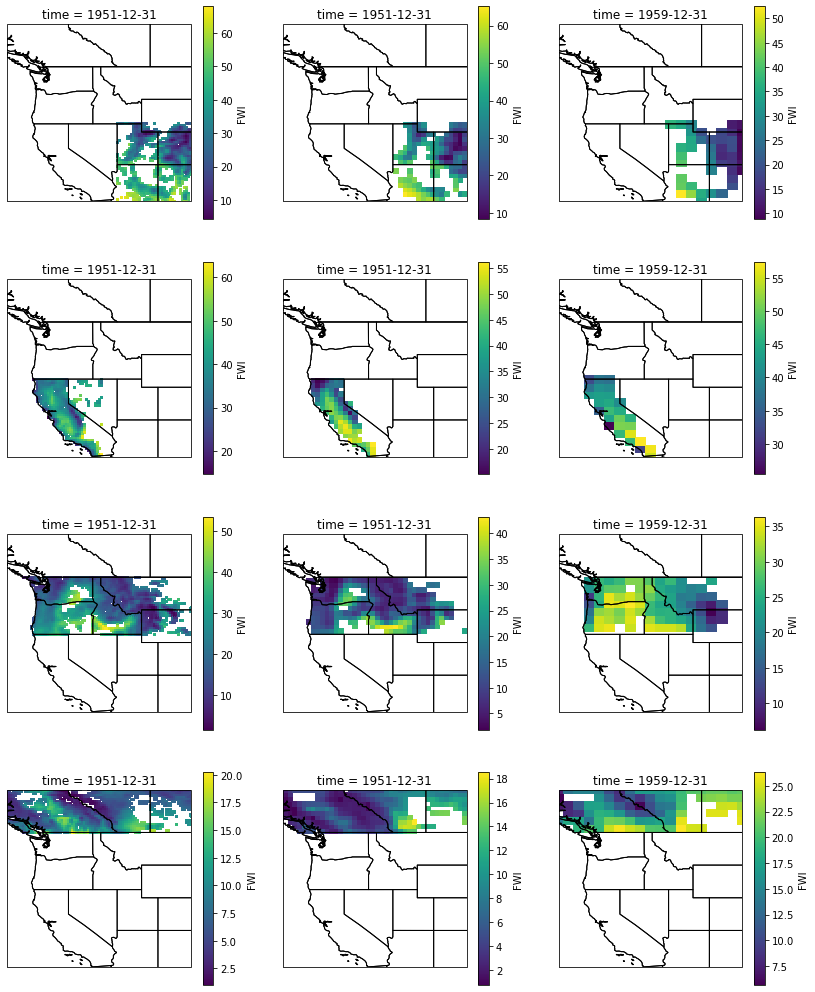

In [9]:
ERA5 = ERA5.where(era5_vege_mask>0)
d4pdf = d4pdf.where(d4pdf_vege_mask>0)
cam5 = cam5.where(cam5_vege_mask>0)

fig,axs = plt.subplots(4,3,figsize=(14,18),subplot_kw=dict(projection=ccrs.PlateCarree()))
axs = axs.flatten()

i=0
for subregion in subregions:
    for da in [ERA5,d4pdf,cam5]:

        sr = subregions[subregion]
        
        if i in [0,3,6,9]:
            four_corners = da.sel(latitude=slice(sr[1],sr[0]),longitude=slice(sr[2],sr[3]))
        else:
            four_corners = da.sel(latitude=slice(sr[0],sr[1]),longitude=slice(sr[2],sr[3]))

        four_corners.isel(time=0).plot(ax=axs[i])

        axs[i].coastlines()  # cartopy function
        axs[i].add_feature(cf.BORDERS)
        axs[i].add_feature(cf.STATES)
        axs[i].set_extent([232.5,255, 32.5,54.18])
        
        i +=1


In [4]:
def setup_figure():
    
    gs = fig.add_gridspec(6,9)
    gs.update(wspace=1.5, hspace=0.3)

    # ANT signal map
    ax1 = fig.add_subplot(gs[0:3, 0:3], projection=ccrs.PlateCarree())
    ax1.coastlines(resolution='auto', color='k')
    ax1.set_extent([232.5,255, 32.5,54.18], crs=ccrs.PlateCarree())

    # NOISE map
    ax2 = fig.add_subplot(gs[3:6, 0:3], projection=ccrs.PlateCarree())
    ax2.coastlines(resolution='auto', color='k')
    ax2.set_extent([232.5,255, 32.5,54.18], crs=ccrs.PlateCarree())

    # subregion timeseries
    ax3 = fig.add_subplot(gs[0:2, 3:6])
    plt.setp(ax3.get_xticklabels(), visible=False)
    
    ax4 = fig.add_subplot(gs[0:2, 6:9])
    plt.setp(ax4.get_xticklabels(), visible=False)
    
    ax5 = fig.add_subplot(gs[2:4, 3:6], sharex=ax3)
    plt.setp(ax5.get_xticklabels(), visible=False)
    
    ax6 = fig.add_subplot(gs[2:4, 6:9], sharex=ax4)
    plt.setp(ax6.get_xticklabels(), visible=False)
    
    ax7 = fig.add_subplot(gs[4:6, 3:6], sharex=ax3)
    ax8 = fig.add_subplot(gs[4:6, 6:9], sharex=ax4)


    return((ax1,ax2,[ax3,ax4,ax5,ax6,ax7,ax8]))

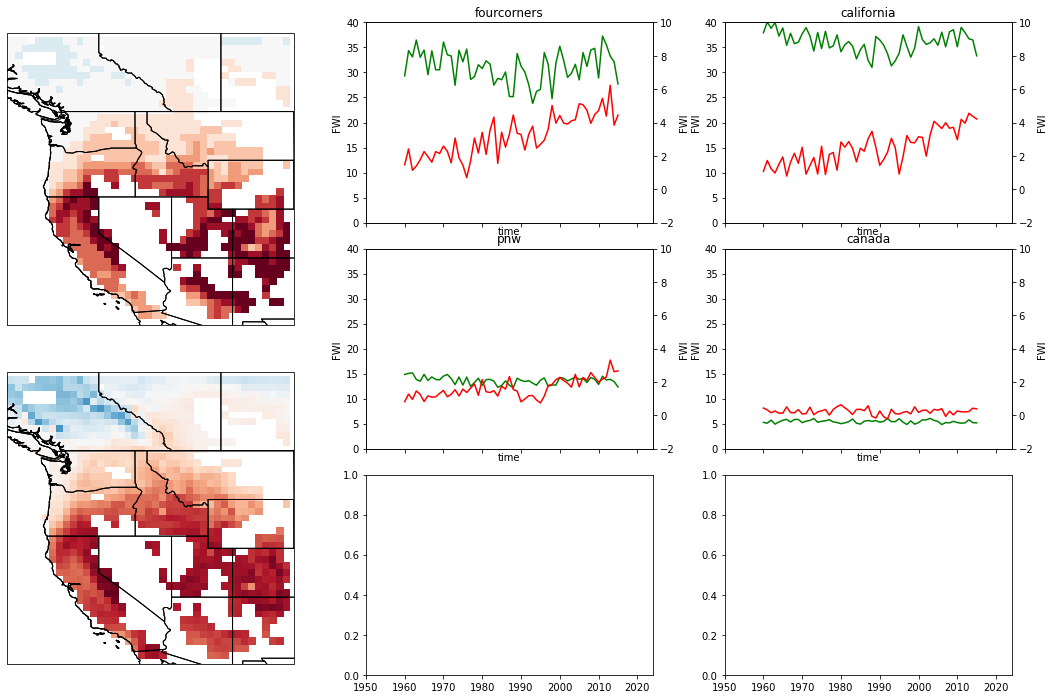

In [31]:
'''
Create figure for d4PDF of ANT signal map w/ subregions, NOISE map, and timeseries
'''
fig = plt.figure(figsize=(18,12))
sig_ax,noise_ax,ts_axes = setup_figure()

cmap = cm.get_cmap('RdBu_r', 15)

font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 22,
        }

# get d4PDF data
era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/d4pdf_resolution/FWI_6month_fire_season_d4pdf_resolution.nc')
Ant_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_Ant_ensMean.nc')
Nat_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_NAT_ensMean.nc')
noise_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/noise/absolute_noise/FWI_absolute_noise_all_and_nat_ensMean.nc')

Ant_da = Ant_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
Ant_da = Ant_da.sel(time=slice('1959','2014'))
Ant_da = Ant_da.where(d4pdf_vege_mask>0)
Ant_da = Ant_da.where(~era5_da.isnull())

Nat_da = Nat_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
Nat_da = Nat_da.sel(time=slice('1959','2014'))
Nat_da = Nat_da.where(d4pdf_vege_mask>0)
Nat_da = Nat_da.where(~era5_da.isnull())

# plot ANT signal map
sig = xr.apply_ufunc(get_linregress_slope, Ant_da, input_core_dims=[["time"]], vectorize = True)
ant_im = sig.plot(ax=sig_ax,transform=ccrs.PlateCarree(),vmin=-0.08,vmax=0.08,cmap=cmap,add_colorbar=False)
sig_ax.coastlines()  # cartopy function
sig_ax.add_feature(cf.BORDERS)
sig_ax.add_feature(cf.STATES)
sig_ax.set_extent([232.5,256, 31.5,55.3])

# plot noise

noise = noise_da.mean('time')
sig_to_noise = sig/noise
sig_to_noise.plot(ax=noise_ax,transform=ccrs.PlateCarree(),add_colorbar=False)

#noise.plot(ax=noise_ax,transform=ccrs.PlateCarree(),add_colorbar=False)
noise_ax.coastlines()  # cartopy function
noise_ax.add_feature(cf.BORDERS)
noise_ax.add_feature(cf.STATES)
noise_ax.set_extent([232.5,256, 31.5,55.3])

# plot subregional time series

for i,subregion in enumerate(subregions):
    
    ax1 = ts_axes[i]
    ax2 = ax1.twinx()
    
    sr = subregions[subregion]
    ant_sr = Ant_da.sel(latitude=slice(sr[0],sr[1]),longitude=slice(sr[2],sr[3]))
    nat_sr = Nat_da.sel(latitude=slice(sr[0],sr[1]),longitude=slice(sr[2],sr[3]))
    
    nat_sr.mean(['latitude','longitude']).plot(ax=ax1,label='NAT',c='green')
    ant_sr.mean(['latitude','longitude']).plot(ax=ax2,label='ALL',c='red')
    
    
    ax1.set_title(subregion)
    ax1.set_ylim(0,40)
    ax2.set_ylim(-2,10)
    
    ax1.set_xlim('1950','2024')
    

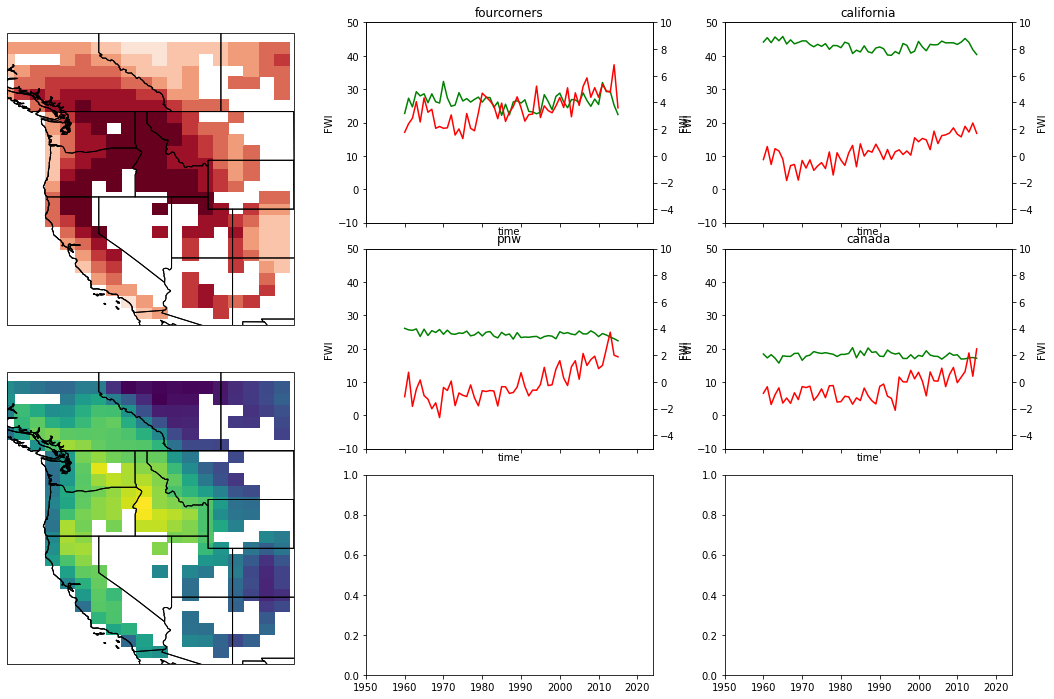

In [30]:
'''
Create figure for CAM5 of ANT signal map w/ subregions, NOISE map, and timeseries
'''
fig = plt.figure(figsize=(18,12))
sig_ax,noise_ax,ts_axes = setup_figure()

cmap = cm.get_cmap('RdBu_r', 15)

font = {'family': 'sans-serif',
        'color':  'black',
        'weight': 'normal',
        'size': 22,
        }

# get CAM5 data
era5_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/ERA5/model-style/6month_fire_season/cam5_resolution/FWI_6month_fire_season_cam5_resolution.nc')
Ant_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_Ant_ensMean.nc')
Nat_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_Nat_ensMean.nc')
noise_da = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/noise/absolute_noise/FWI_absolute_noise_all_and_nat_ensMean.nc')

Ant_da = Ant_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
Ant_da = Ant_da.sel(time=slice('1959','2014'))
Ant_da = Ant_da.where(cam5_vege_mask>0)
Ant_da = Ant_da.where(~era5_da.isnull())

Nat_da = Nat_da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
Nat_da = Nat_da.sel(time=slice('1959','2014'))
Nat_da = Nat_da.where(cam5_vege_mask>0)
Nat_da = Nat_da.where(~era5_da.isnull())

# plot ANT signal map
sig = xr.apply_ufunc(get_linregress_slope, Ant_da, input_core_dims=[["time"]], vectorize = True)
ant_im = sig.plot(ax=sig_ax,transform=ccrs.PlateCarree(),vmin=-0.08,vmax=0.08,cmap=cmap,add_colorbar=False)
sig_ax.coastlines()  # cartopy function
sig_ax.add_feature(cf.BORDERS)
sig_ax.add_feature(cf.STATES)
sig_ax.set_extent([232.5,256, 31.5,55.3])

# plot noise

noise = noise_da.mean('time')
sig_to_noise = sig/noise
sig_to_noise.plot(ax=noise_ax,transform=ccrs.PlateCarree(),add_colorbar=False)

#noise.plot(ax=noise_ax,transform=ccrs.PlateCarree(),add_colorbar=False)
noise_ax.coastlines()  # cartopy function
noise_ax.add_feature(cf.BORDERS)
noise_ax.add_feature(cf.STATES)
noise_ax.set_extent([232.5,256, 31.5,55.3])

# plot subregional time series

for i,subregion in enumerate(subregions):
    
    ax1 = ts_axes[i]
    ax2 = ax1.twinx()
    
    sr = subregions[subregion]
    ant_sr = Ant_da.sel(latitude=slice(sr[0],sr[1]),longitude=slice(sr[2],sr[3]))
    nat_sr = Nat_da.sel(latitude=slice(sr[0],sr[1]),longitude=slice(sr[2],sr[3]))
    
    nat_sr.mean(['latitude','longitude']).plot(ax=ax1,label='NAT',c='green')
    ant_sr.mean(['latitude','longitude']).plot(ax=ax2,label='ALL',c='red')
    
    
    ax1.set_title(subregion)
    ax1.set_ylim(-10,50)
    ax2.set_ylim(-5,10)
    
    ax1.set_xlim('1950','2024')
    

In [24]:
sig/noise

<xarray.DataArray 'FWI' (lev: 1, latitude: 24, longitude: 19)>
array([[[       nan,        nan,        nan,        nan,        nan,
                nan,        nan,        nan,        nan, 0.01761506,
         0.01657223,        nan,        nan,        nan, 0.01179699,
                nan,        nan,        nan,        nan],
        [       nan,        nan,        nan,        nan,        nan,
                nan,        nan,        nan, 0.01255045, 0.01807671,
                nan,        nan, 0.01556494, 0.01517252, 0.01224236,
         0.00969942, 0.01185466,        nan,        nan],
        [       nan,        nan,        nan,        nan,        nan,
                nan,        nan, 0.01875842, 0.0198109 ,        nan,
                nan,        nan, 0.01346004, 0.01323538,        nan,
                nan,        nan, 0.01252261,        nan],
        [       nan,        nan,        nan,        nan,        nan,
                nan, 0.02013545, 0.02176146,        nan,        nan,
                nan,        nan, 0.013224  ,        nan,        nan,
                nan,        nan, 0.01113583,        nan],
        [       nan,        nan,        nan,        nan,        nan,
         0.01332498, 0.02218335, 0.02188021,        nan,        nan,
                nan,        nan,        nan,        nan,        nan,
         0.01189943,        nan, 0.00858958, 0.00972259],
...
        [0.01328177, 0.01793849, 0.02314174, 0.0238719 , 0.02253748,
         0.02228192, 0.02254554, 0.02224084, 0.02179076, 0.01974497,
         0.0157014 , 0.00982427, 0.0073449 ,        nan,        nan,
                nan,        nan,        nan, 0.00918308],
        [       nan, 0.02049695, 0.0225113 , 0.01953859, 0.01838952,
         0.02066813, 0.02234078, 0.02274342, 0.01936571, 0.01495202,
         0.01052639, 0.00660337, 0.00675987,        nan,        nan,
         0.00854289, 0.00818329,        nan, 0.00973614],
        [0.0147047 , 0.02087373, 0.01908856, 0.01617859, 0.01672781,
         0.01955205, 0.02136216, 0.02124897, 0.01667644, 0.01044024,
         0.00641198, 0.00634291, 0.00638136,        nan,        nan,
                nan, 0.00792453, 0.00911093, 0.01026195],
        [0.01669665,        nan,        nan,        nan, 0.0143422 ,
         0.01754749, 0.01868565, 0.01470928, 0.01152099, 0.00727438,
         0.00439477, 0.00529598, 0.00529281,        nan, 0.00593795,
         0.00754862, 0.00843891, 0.00987749, 0.01170424],
        [0.01604736, 0.01470404, 0.01367357, 0.01271872, 0.01263175,
         0.01459618, 0.01434431, 0.00777794, 0.00455071, 0.00521409,
         0.00458993, 0.00497741, 0.00476143, 0.00485507, 0.00586605,
         0.00735134, 0.00840303, 0.00970543, 0.01115644]]])
Coordinates:
  * latitude   (latitude) float64 32.51 33.46 34.4 35.34 ... 52.3 53.25 54.19
  * longitude  (longitude) float64 232.5 233.8 235.0 236.2 ... 252.5 253.8 255.0
Dimensions without coordinates: lev

In [23]:
sig

<xarray.DataArray 'FWI' (lev: 1, latitude: 24, longitude: 19)>
array([[[       nan,        nan,        nan,        nan,        nan,
                nan,        nan,        nan,        nan, 0.02601355,
         0.03325848,        nan,        nan,        nan, 0.05404636,
                nan,        nan,        nan,        nan],
        [       nan,        nan,        nan,        nan,        nan,
                nan,        nan,        nan, 0.01502175, 0.03075771,
                nan,        nan, 0.04851109, 0.06021242, 0.05499889,
         0.0447242 , 0.05103424,        nan,        nan],
        [       nan,        nan,        nan,        nan,        nan,
                nan,        nan, 0.03122643, 0.03580528,        nan,
                nan,        nan, 0.0509295 , 0.06033638,        nan,
                nan,        nan, 0.04866186,        nan],
        [       nan,        nan,        nan,        nan,        nan,
                nan, 0.03522661, 0.04444723,        nan,        nan,
                nan,        nan, 0.05345035,        nan,        nan,
                nan,        nan, 0.04000232,        nan],
        [       nan,        nan,        nan,        nan,        nan,
         0.018062  , 0.04583753, 0.05649349,        nan,        nan,
                nan,        nan,        nan,        nan,        nan,
         0.05572631,        nan, 0.03106638, 0.02539313],
...
        [0.03310453, 0.05094005, 0.0627902 , 0.05579266, 0.06403517,
         0.06295112, 0.06118927, 0.06364802, 0.05996375, 0.05667815,
         0.05020684, 0.03562542, 0.03251711,        nan,        nan,
                nan,        nan,        nan, 0.04272385],
        [       nan, 0.03772246, 0.04228302, 0.04913369, 0.04998173,
         0.0545718 , 0.05620796, 0.05289104, 0.04478554, 0.03846695,
         0.03176356, 0.02461096, 0.02928568,        nan,        nan,
         0.03918356, 0.03754382,        nan, 0.04458072],
        [0.0248117 , 0.03719134, 0.04235245, 0.04270139, 0.04327608,
         0.04742598, 0.04657348, 0.04258222, 0.02743349, 0.02612803,
         0.01807096, 0.02015697, 0.02668336,        nan,        nan,
                nan, 0.03728805, 0.04179079, 0.04630595],
        [0.02594453,        nan,        nan,        nan, 0.03500721,
         0.03859997, 0.03399831, 0.03177341, 0.02297947, 0.01720694,
         0.01295048, 0.01813064, 0.02174864,        nan, 0.02636896,
         0.03344204, 0.03671595, 0.04258634, 0.04996785],
        [0.02794522, 0.03390919, 0.03234126, 0.03014276, 0.02904465,
         0.02872478, 0.02509622, 0.01857091, 0.0123536 , 0.01440613,
         0.01391339, 0.01773552, 0.01896828, 0.01996783, 0.02405433,
         0.02953537, 0.03343174, 0.03815977, 0.04376754]]])
Coordinates:
  * latitude   (latitude) float64 32.51 33.46 34.4 35.34 ... 52.3 53.25 54.19
  * longitude  (longitude) float64 232.5 233.8 235.0 236.2 ... 252.5 253.8 255.0
Dimensions without coordinates: lev

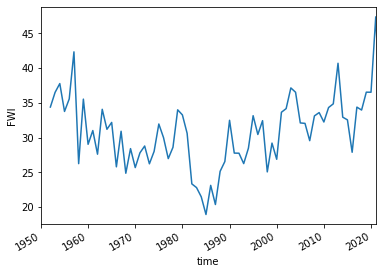

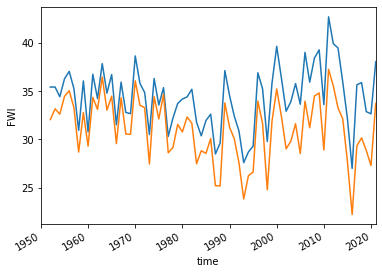

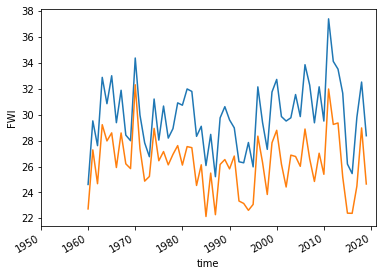

In [47]:
d4pdf = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc')
cam5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_All_ensMean.nc')


for product in ['era5','d4pdf','cam5']:
    
    # if ERA5, just plot regional time series
    if product == 'era5':
        ERA5.sel(latitude=slice(42,32),longitude=slice(246,256)).mean(['latitude','longitude']).plot()
        plt.xlim('1950','2021')
        plt.show()
        plt.close()
        
    if product == 'd4pdf':
        
        ALL = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc').where(d4pdf_vege_mask>0).sel(latitude=slice(32,42),longitude=slice(246,256))
        NAT = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_NAT_ensMean.nc').where(d4pdf_vege_mask>0).sel(latitude=slice(32,42),longitude=slice(246,256))
        ANT = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_Ant_ensMean.nc').where(d4pdf_vege_mask>0).sel(latitude=slice(32,42),longitude=slice(246,256))
            
        ALL.mean(['latitude','longitude']).plot(label='ALL')
        NAT.mean(['latitude','longitude']).plot(label='NAT')
        #ANT.mean(['latitude','longitude']).plot(label='ANT')
        plt.xlim('1950','2021')
        plt.show()
        plt.close()
        
    if product == 'cam5':
        
        ALL = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_All_ensMean.nc').where(cam5_vege_mask>0).sel(latitude=slice(32,42),longitude=slice(246,256))
        NAT = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_Nat_ensMean.nc').where(cam5_vege_mask>0).sel(latitude=slice(32,42),longitude=slice(246,256))
        ANT = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_Ant_ensMean.nc').where(cam5_vege_mask>0).sel(latitude=slice(32,42),longitude=slice(246,256))

        ALL.mean(['latitude','longitude']).plot(label='ALL')
        NAT.mean(['latitude','longitude']).plot(label='NAT')
        #ANT.mean(['latitude','longitude']).plot(label='ANT')
        plt.xlim('1950','2021')
        plt.show()
        plt.close()

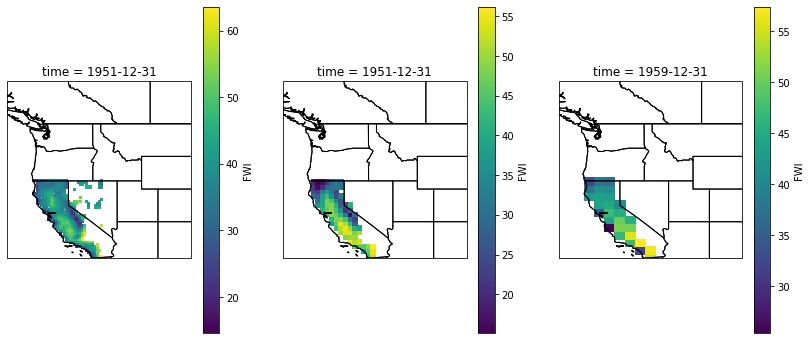

In [38]:
fig,axs = plt.subplots(1,3,figsize=(14,6),subplot_kw=dict(projection=ccrs.PlateCarree()))
axs = axs.flatten()

for i,da in enumerate([ERA5,d4pdf,cam5]):

    if i == 0:
        four_corners = da.sel(latitude=slice(42,32),longitude=slice(232,244))
    else:
        four_corners = da.sel(latitude=slice(32,42),longitude=slice(232,244))
        
    four_corners.isel(time=0).plot(ax=axs[i])

    axs[i].coastlines()  # cartopy function
    axs[i].add_feature(cf.BORDERS)
    axs[i].add_feature(cf.STATES)
    axs[i].set_extent([232.5,255, 32.5,54.18])


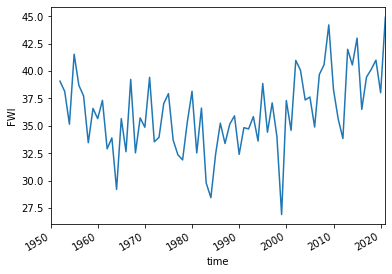

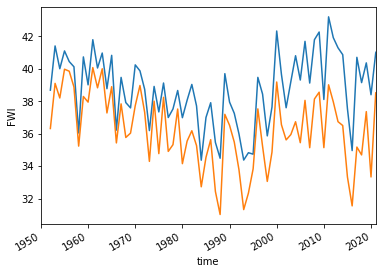

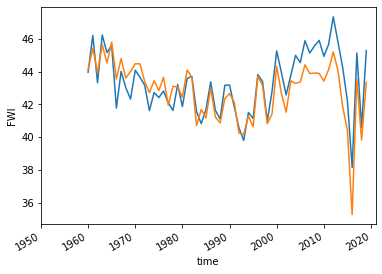

In [45]:
d4pdf = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc')
cam5 = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_All_ensMean.nc')


for product in ['era5','d4pdf','cam5']:
    
    # if ERA5, just plot regional time series
    if product == 'era5':
        ERA5.sel(latitude=slice(42,32),longitude=slice(232,244)).mean(['latitude','longitude']).plot()
        plt.xlim('1950','2021')
        plt.show()
        plt.close()
        
    if product == 'd4pdf':
        
        ALL = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc').where(d4pdf_vege_mask>0).sel(latitude=slice(32,42),longitude=slice(232,244))
        NAT = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_NAT_ensMean.nc').where(d4pdf_vege_mask>0).sel(latitude=slice(32,42),longitude=slice(232,244))
        ANT = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_Ant_ensMean.nc').where(d4pdf_vege_mask>0).sel(latitude=slice(32,42),longitude=slice(232,244))

        ALL.mean(['latitude','longitude']).plot(label='ALL')
        NAT.mean(['latitude','longitude']).plot(label='NAT')
        #ANT.mean(['latitude','longitude']).plot(label='ANT')
        plt.xlim('1950','2021')
        plt.show()
        plt.close()
        
    if product == 'cam5':
        
        ALL = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_All_ensMean.nc').where(cam5_vege_mask>0).sel(latitude=slice(32,42),longitude=slice(232,244))
        NAT = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_Nat_ensMean.nc').where(cam5_vege_mask>0).sel(latitude=slice(32,42),longitude=slice(232,244))
        ANT = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_Ant_ensMean.nc').where(cam5_vege_mask>0).sel(latitude=slice(32,42),longitude=slice(232,244))
        
        ALL.mean(['latitude','longitude']).plot(label='ALL')
        NAT.mean(['latitude','longitude']).plot(label='NAT')
        #ANT.mean(['latitude','longitude']).plot(label='ANT')
        plt.xlim('1950','2021')
        plt.show()
        plt.close()

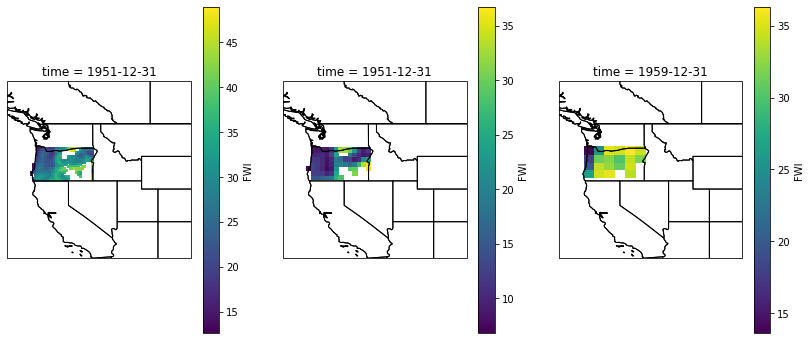

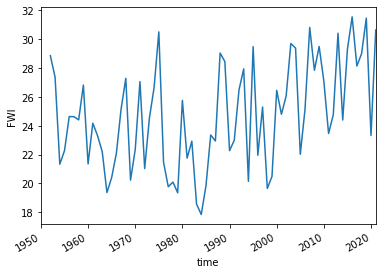

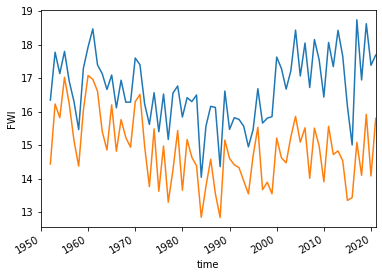

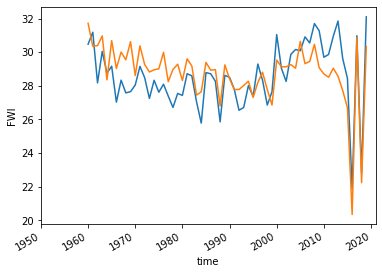

In [58]:
ERA5 = ERA5.where(era5_vege_mask>0)
d4pdf = d4pdf.where(d4pdf_vege_mask>0)
cam5 = cam5.where(cam5_vege_mask>0)

fig,axs = plt.subplots(1,3,figsize=(14,6),subplot_kw=dict(projection=ccrs.PlateCarree()))
axs = axs.flatten()

box = [[42,46],[232,243]]
for i,da in enumerate([ERA5,d4pdf,cam5]):

    if i == 0:
        four_corners = da.sel(latitude=slice(box[0][1],box[0][0]),longitude=slice(box[1][0],box[1][1]))
    else:
        four_corners = da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
        
    four_corners.isel(time=0).plot(ax=axs[i])

    axs[i].coastlines()  # cartopy function
    axs[i].add_feature(cf.BORDERS)
    axs[i].add_feature(cf.STATES)
    axs[i].set_extent([232.5,255, 32.5,54.18])

plt.show()
plt.close()

for product in ['era5','d4pdf','cam5']:
    
    # if ERA5, just plot regional time series
    if product == 'era5':
        ERA5.sel(latitude=slice(box[0][1],box[0][0]),longitude=slice(box[1][0],box[1][1])).mean(['latitude','longitude']).plot()
        plt.xlim('1950','2021')
        plt.show()
        plt.close()
        
    if product == 'd4pdf':
        
        ALL = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc').where(d4pdf_vege_mask>0).sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
        NAT = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_NAT_ensMean.nc').where(d4pdf_vege_mask>0).sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
        ANT = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_Ant_ensMean.nc').where(d4pdf_vege_mask>0).sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

        ALL.mean(['latitude','longitude']).plot(label='ALL')
        NAT.mean(['latitude','longitude']).plot(label='NAT')
        #ANT.mean(['latitude','longitude']).plot(label='ANT')
        plt.xlim('1950','2021')
        plt.show()
        plt.close()
        
    if product == 'cam5':
        
        ALL = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_All_ensMean.nc').where(cam5_vege_mask>0).sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
        NAT = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_Nat_ensMean.nc').where(cam5_vege_mask>0).sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
        ANT = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_Ant_ensMean.nc').where(cam5_vege_mask>0).sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
        
        ALL.mean(['latitude','longitude']).plot(label='ALL')
        NAT.mean(['latitude','longitude']).plot(label='NAT')
        #ANT.mean(['latitude','longitude']).plot(label='ANT')
        plt.xlim('1950','2021')
        plt.show()
        plt.close()

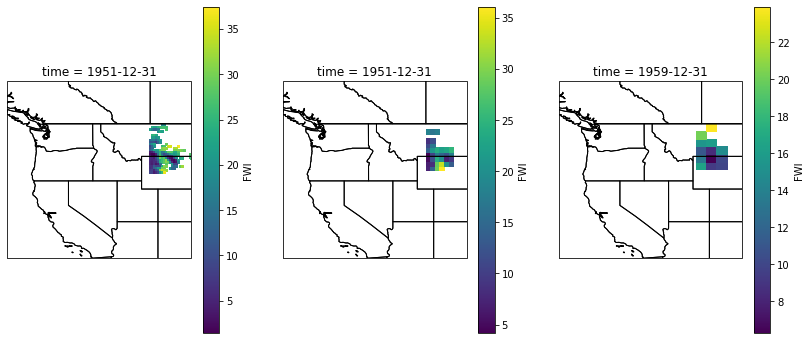

No handles with labels found to put in legend.


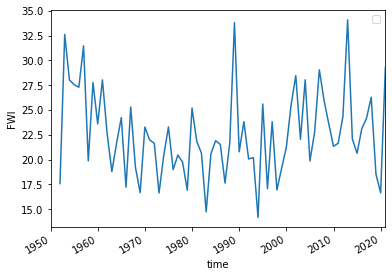

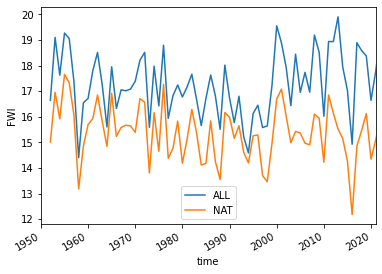

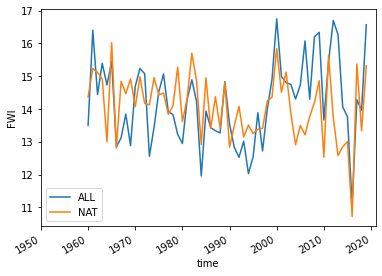

In [62]:
ERA5 = ERA5.where(era5_vege_mask>0)
d4pdf = d4pdf.where(d4pdf_vege_mask>0)
cam5 = cam5.where(cam5_vege_mask>0)

fig,axs = plt.subplots(1,3,figsize=(14,6),subplot_kw=dict(projection=ccrs.PlateCarree()))
axs = axs.flatten()

box = [[43,49],[250,255]]
for i,da in enumerate([ERA5,d4pdf,cam5]):

    if i == 0:
        four_corners = da.sel(latitude=slice(box[0][1],box[0][0]),longitude=slice(box[1][0],box[1][1]))
    else:
        four_corners = da.sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
        
    four_corners.isel(time=0).plot(ax=axs[i])

    axs[i].coastlines()  # cartopy function
    axs[i].add_feature(cf.BORDERS)
    axs[i].add_feature(cf.STATES)
    axs[i].set_extent([232.5,255, 32.5,54.18])

plt.show()
plt.close()

for product in ['era5','d4pdf','cam5']:
    
    # if ERA5, just plot regional time series
    if product == 'era5':
        ERA5.sel(latitude=slice(box[0][1],box[0][0]),longitude=slice(box[1][0],box[1][1])).mean(['latitude','longitude']).plot()
        plt.xlim('1950','2021')
        plt.legend()
        plt.show()
        plt.close()
        
    if product == 'd4pdf':
        
        ALL = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc').where(d4pdf_vege_mask>0).sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
        NAT = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_NAT_ensMean.nc').where(d4pdf_vege_mask>0).sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
        ANT = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_Ant_ensMean.nc').where(d4pdf_vege_mask>0).sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

        ALL.mean(['latitude','longitude']).plot(label='ALL')
        NAT.mean(['latitude','longitude']).plot(label='NAT')
        #ANT.mean(['latitude','longitude']).plot(label='ANT')
        plt.xlim('1950','2021')
        plt.legend()
        plt.show()
        plt.close()
        
    if product == 'cam5':
        
        ALL = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_All_ensMean.nc').where(cam5_vege_mask>0).sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
        NAT = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_Nat_ensMean.nc').where(cam5_vege_mask>0).sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
        ANT = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_Ant_ensMean.nc').where(cam5_vege_mask>0).sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
        
        ALL.mean(['latitude','longitude']).plot(label='ALL')
        NAT.mean(['latitude','longitude']).plot(label='NAT')
        #ANT.mean(['latitude','longitude']).plot(label='ANT')
        plt.xlim('1950','2021')
        plt.legend()
        plt.show()
        plt.close()

In [66]:
box = [(32,55),(232,256)]
ALL = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_All_ensMean.nc').where(cam5_vege_mask>0).sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
NAT = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/FWI_Nat_ensMean.nc').where(cam5_vege_mask>0).sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))



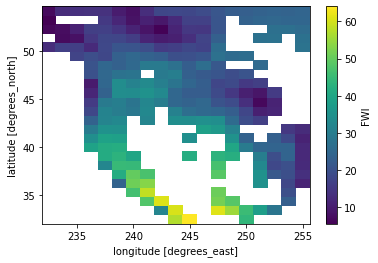

In [68]:
ALL.mean('time').plot()

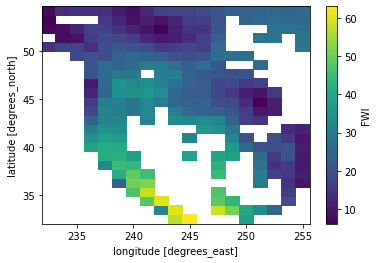

In [69]:
NAT.mean('time').plot()

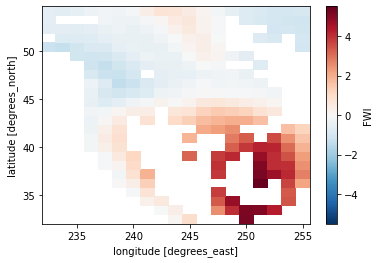

In [70]:
(ALL-NAT).mean('time').plot()

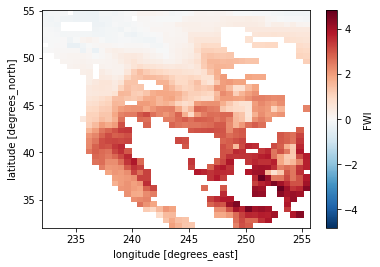

In [71]:
ALL = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_ensMean.nc').where(d4pdf_vege_mask>0).sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
NAT = xr.open_dataarray('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/BC_wind_FWI/BC_wind_FWI_HPB_NAT_ensMean.nc').where(d4pdf_vege_mask>0).sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

(ALL-NAT).mean('time').plot()

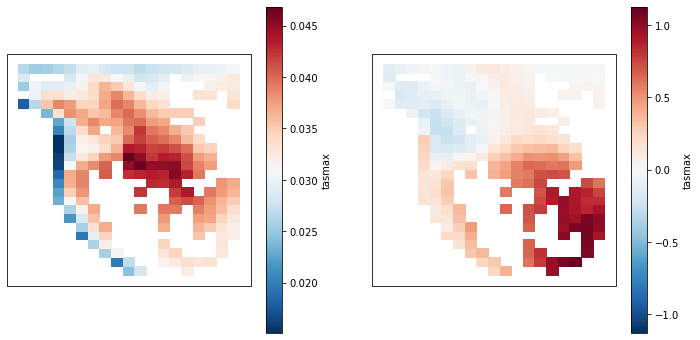

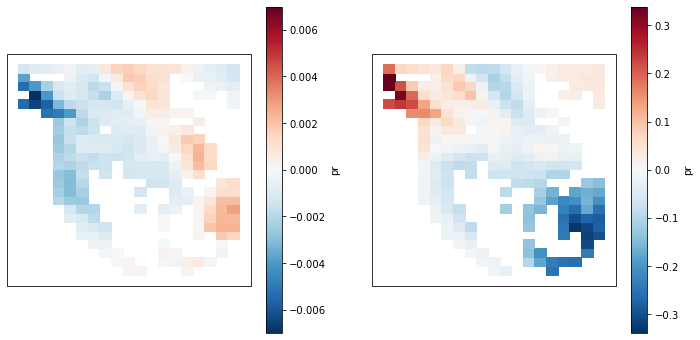

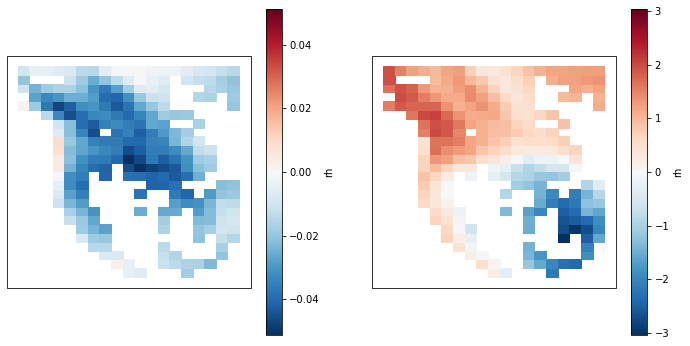

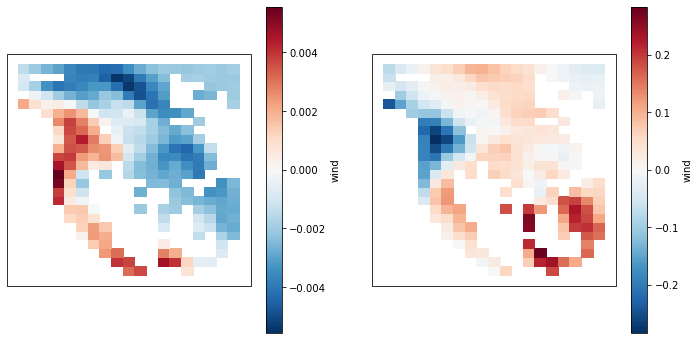

In [104]:
# signal trend vs signal mean

ALL_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/inputs/FWI_inputs_All_ensMean.nc')
ALL_ds = ALL_ds.rename({'lat':'latitude','lon':'longitude'})
ALL_ds = ALL_ds.where(cam5_vege_mask>0).sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

NAT_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/CAM5-1-1/6month_fire_season/inputs/FWI_inputs_Nat_ensMean.nc')
NAT_ds = NAT_ds.rename({'lat':'latitude','lon':'longitude'})
NAT_ds = NAT_ds.where(cam5_vege_mask>0).sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

for var in ['tasmax','pr','rh','wind']:
    
    fig,axs = plt.subplots(1,2,figsize=(12,6),subplot_kw=dict(projection=ccrs.PlateCarree()))#,layout='constrained')
    axs=axs.flatten()
    
    ALL_da = ALL_ds[var]
    NAT_da = NAT_ds[var]
    ANT_da = ALL_da - NAT_da
    

    xr.apply_ufunc(get_linregress_slope, ANT_da, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[0],cmap='RdBu_r')
    ANT_da.mean('time').plot(ax=axs[1])

    plt.show()
    plt.close()



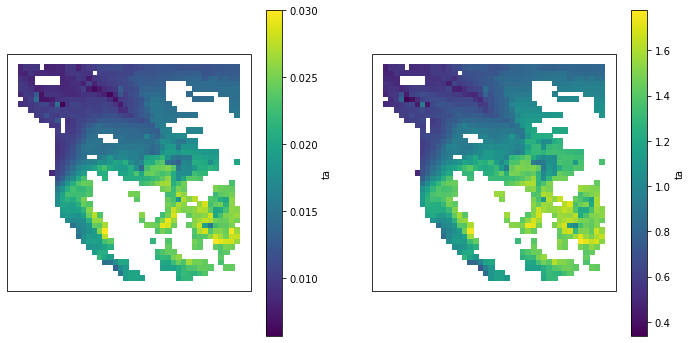

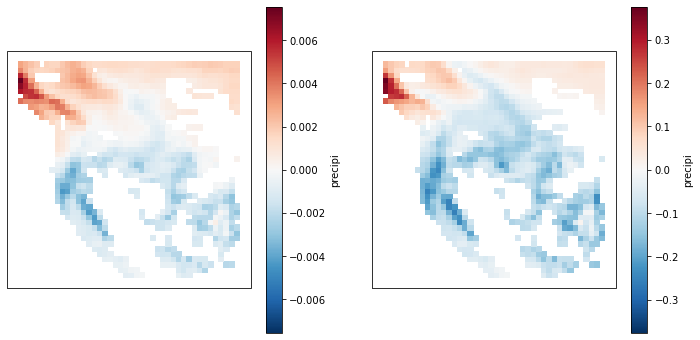

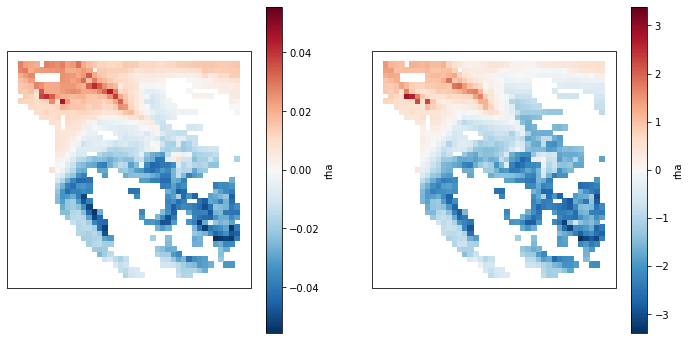

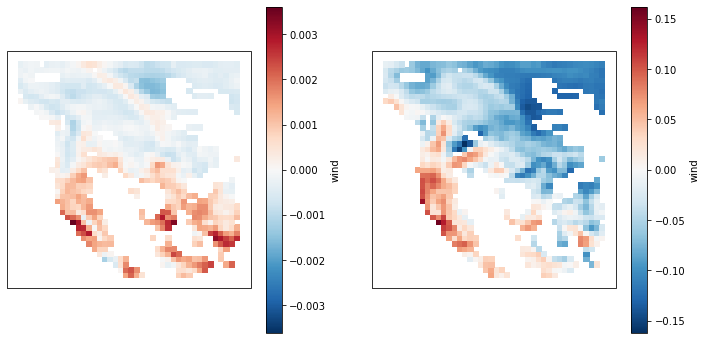

In [98]:
# signal trend vs signal mean

ALL_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/inputs/BC_wind/FWI_inputs_HPB_ensMean.nc').where(d4pdf_vege_mask>0).sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))
NAT_ds = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/inputs/BC_wind/FWI_inputs_HPB_NAT_ensMean.nc').where(d4pdf_vege_mask>0).sel(latitude=slice(box[0][0],box[0][1]),longitude=slice(box[1][0],box[1][1]))

for var in ['ta','precipi','rha','wind']:
    
    fig,axs = plt.subplots(1,2,figsize=(12,6),subplot_kw=dict(projection=ccrs.PlateCarree()))#,layout='constrained')
    axs=axs.flatten()
    
    ALL_da = ALL_ds[var]
    NAT_da = NAT_ds[var]
    ANT_da = ALL_da - NAT_da
    

    xr.apply_ufunc(get_linregress_slope, ANT_da, input_core_dims=[["time"]], vectorize = True).plot(ax=axs[0])
    ANT_da.mean('time').plot(ax=axs[1])

    plt.show()
    plt.close()



In [95]:
Precip_ALL = xr.open_dataset('/nesi/project/niwa00015/queenle/data/fire/d4pdf/FWI/6month_fire_season/inputs/BC_wind/FWI_inputs_HPB_ensMean.nc')


In [96]:
Precip_ALL

<xarray.Dataset>
Dimensions:    (latitude: 92, lev: 1, longitude: 59, time: 71)
Coordinates:
  * time       (time) datetime64[ns] 1951-12-31 1952-12-31 ... 2021-12-31
  * longitude  (longitude) float64 222.8 223.3 223.9 224.4 ... 254.2 254.8 255.4
  * latitude   (latitude) float64 19.94 20.5 21.06 21.62 ... 69.92 70.48 71.05
Dimensions without coordinates: lev
Data variables:
    precipi    (time, lev, latitude, longitude) float64 ...
    ta         (time, lev, latitude, longitude) float32 ...
    rha        (time, lev, latitude, longitude) float32 ...
    wind       (time, lev, latitude, longitude) float64 ...
Attributes:
    CDI:          Climate Data Interface version 2.0.5 (https://mpimet.mpg.de...
    Conventions:  CF-1.6
    history:      Tue Feb 13 11:43:46 2024: cdo ensmean FWI_inputs_HPB_m001_1...
    CDO:          Climate Data Operators version 2.0.5 (https://mpimet.mpg.de...